In [51]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [53]:
df = pd.read_csv("C:\\Users\\User\\Downloads\\insurance.csv.zip")

In [54]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [55]:
df.shape

(1338, 7)

In [56]:
df.size

9366

In [57]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [59]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [60]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(1)

In [62]:
df = df.drop_duplicates()

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df.drop("region",axis=1,inplace = True)

In [65]:
df.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


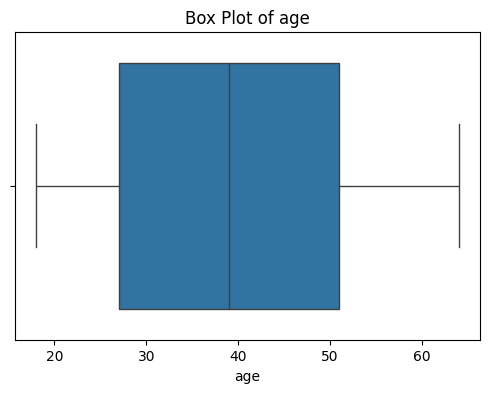

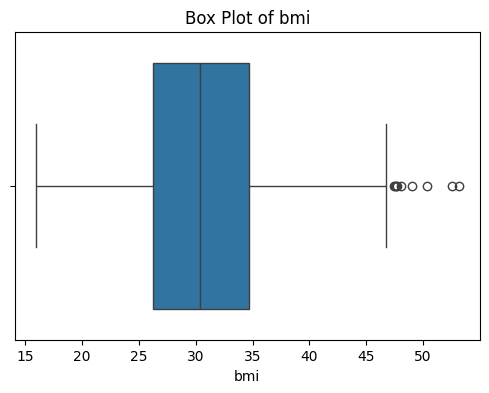

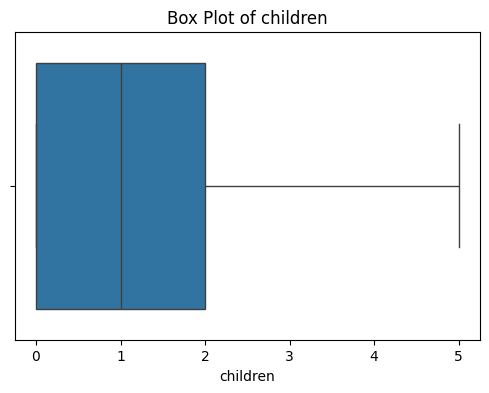

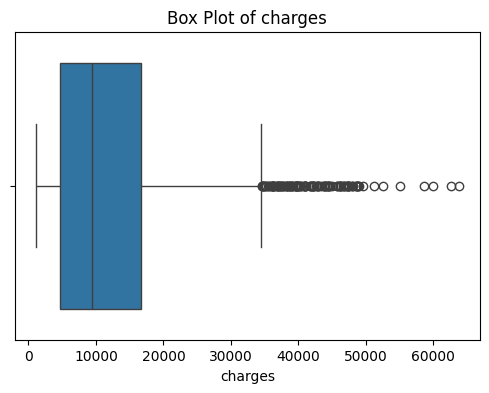

In [66]:
numerical_columns = df.select_dtypes(include=np.number).columns
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

In [67]:
for col in["bmi","charges"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

<Axes: ylabel='bmi'>

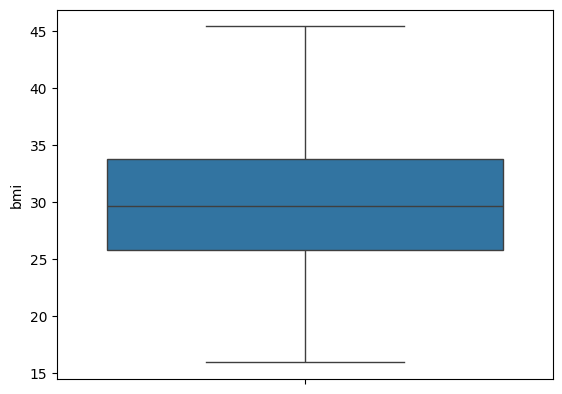

In [68]:
sns.boxplot(df["bmi"],showfliers=False)

<Axes: ylabel='charges'>

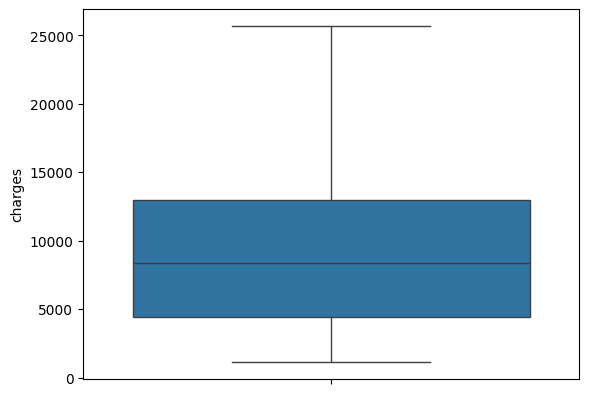

In [69]:
sns.boxplot(df["charges"],showfliers=False)

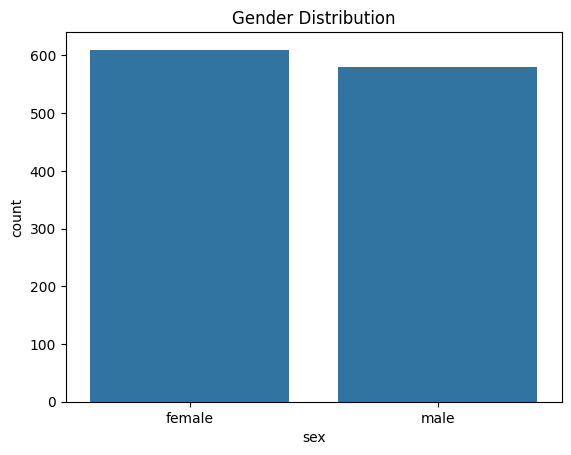

In [70]:
sns.countplot(x="sex", data=df)
plt.title("Gender Distribution")
plt.show()


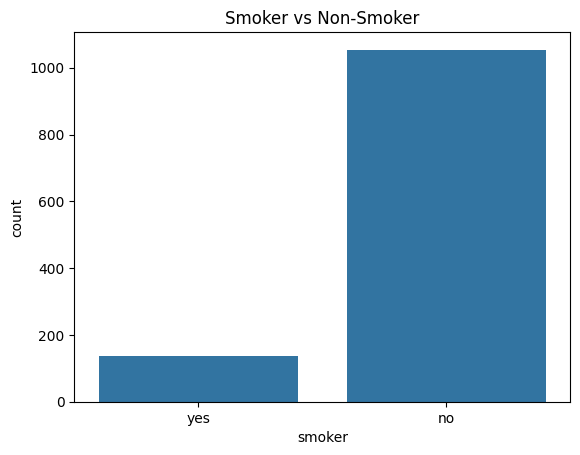

In [71]:
sns.countplot(x="smoker", data=df)
plt.title("Smoker vs Non-Smoker")
plt.show()


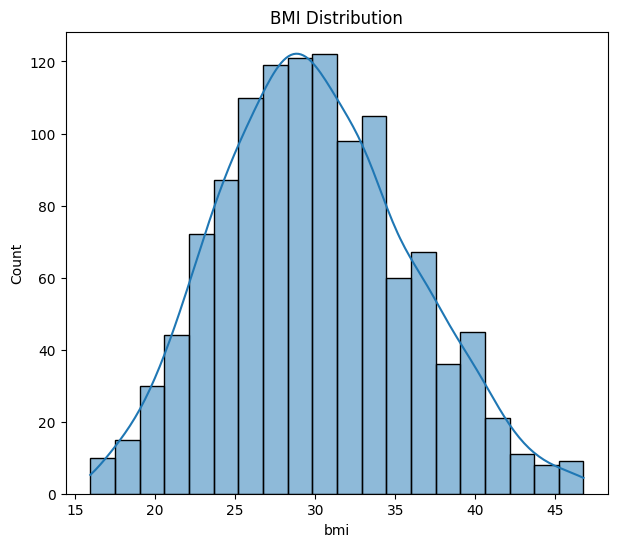

In [73]:
plt.figure(figsize=(7,6))
sns.histplot(df['bmi'],bins=20 ,kde=True,edgecolor='black')
plt.title('BMI Distribution')
plt.show()

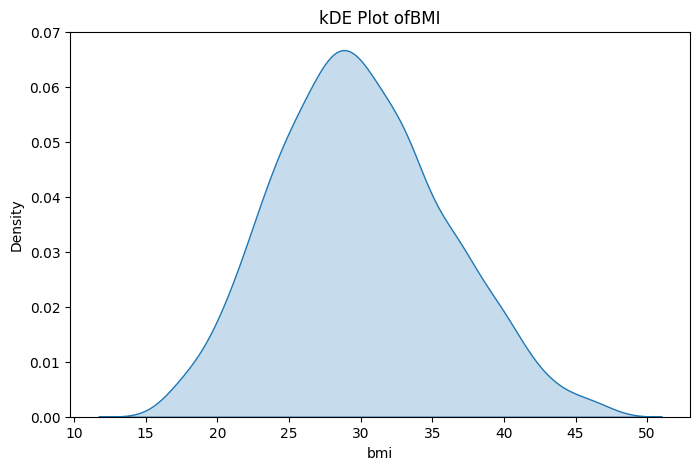

In [76]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['bmi'], fill=True)
plt.title('kDE Plot ofBMI')
plt.xlabel('bmi')
plt.ylabel('Density')
plt.show()

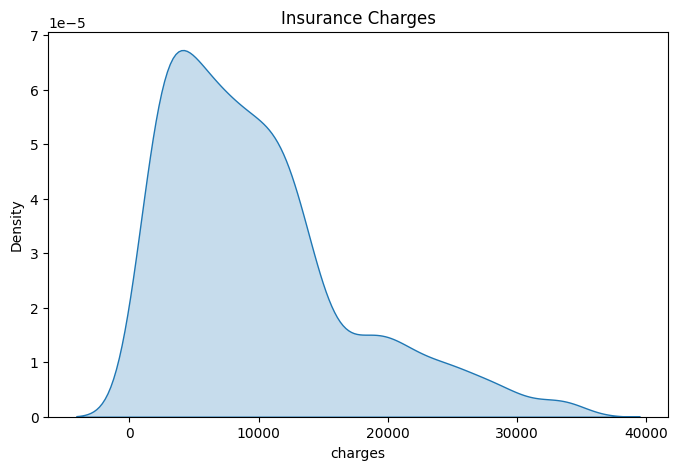

In [77]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['charges'], fill=True)
plt.title('Insurance Charges')
plt.xlabel('charges')
plt.ylabel('Density')
plt.show()

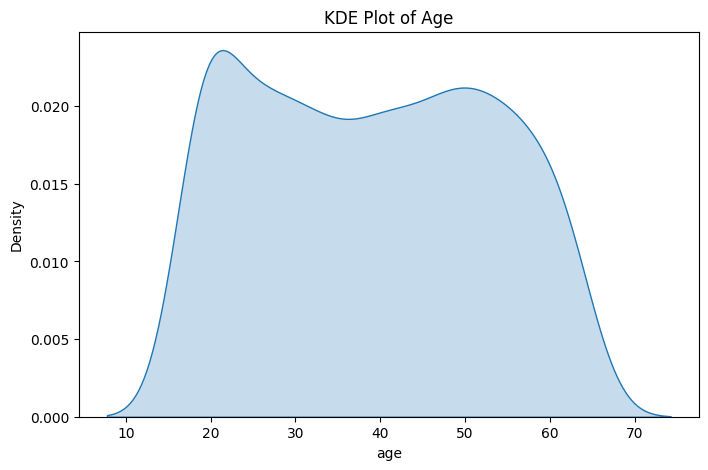

In [78]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['age'], fill=True)
plt.title('KDE Plot of Age')
plt.xlabel('age')
plt.ylabel('Density')
plt.show()

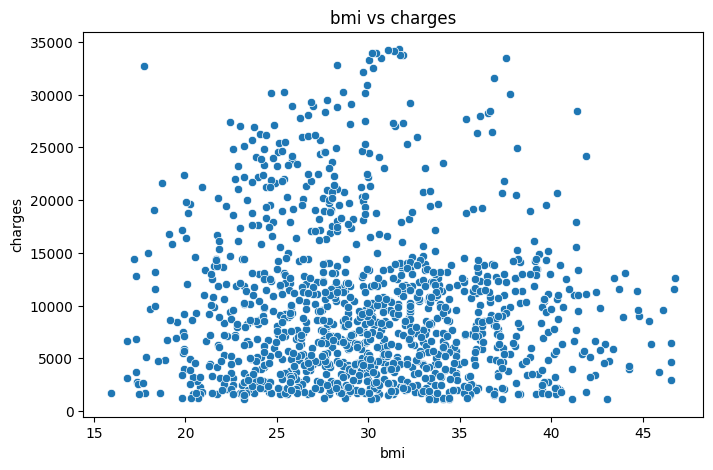

In [79]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='bmi', y='charges')
plt.title('bmi vs charges')
plt.show()

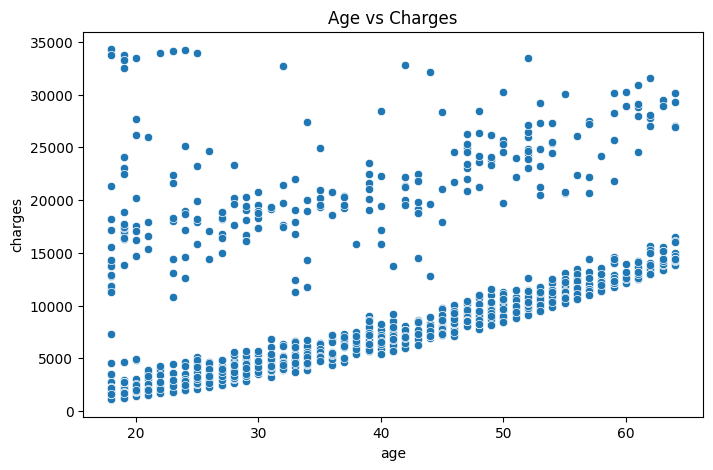

In [80]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='charges')
plt.title('Age vs Charges')
plt.show()

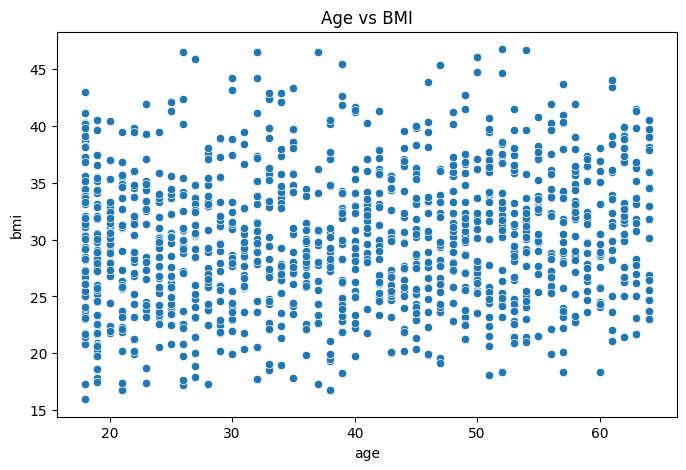

In [81]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='bmi')
plt.title('Age vs BMI')
plt.show()

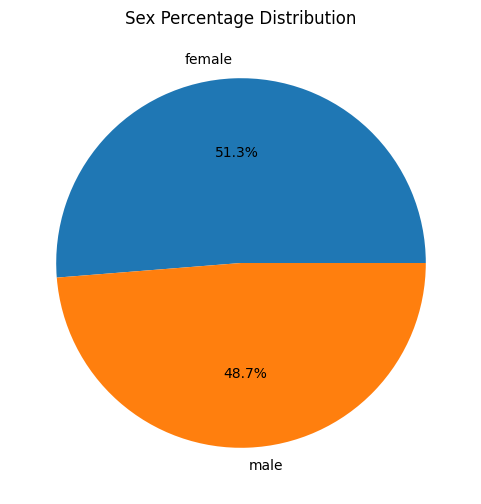

In [82]:
plt.figure(figsize=(6,6))
df['sex'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Sex Percentage Distribution')
plt.ylabel('')
plt.show()

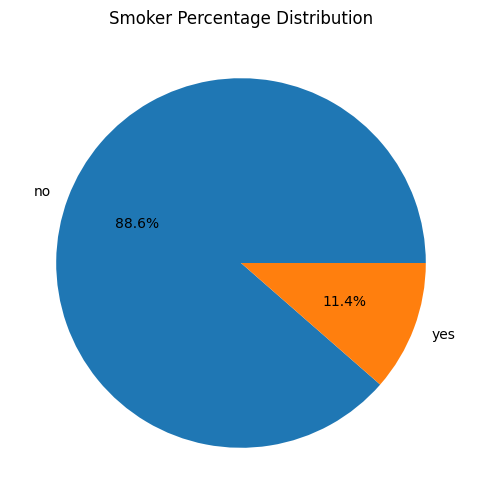

In [83]:
plt.figure(figsize=(6,6))
df['smoker'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Smoker Percentage Distribution')
plt.ylabel('')
plt.show()

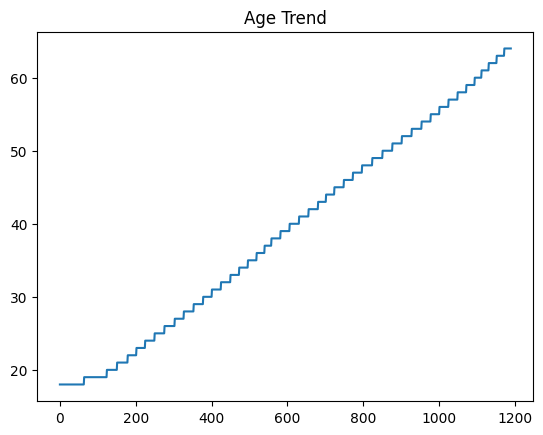

In [84]:
df["age"].sort_values().reset_index(drop=True).plot()
plt.title("Age Trend")
plt.show()

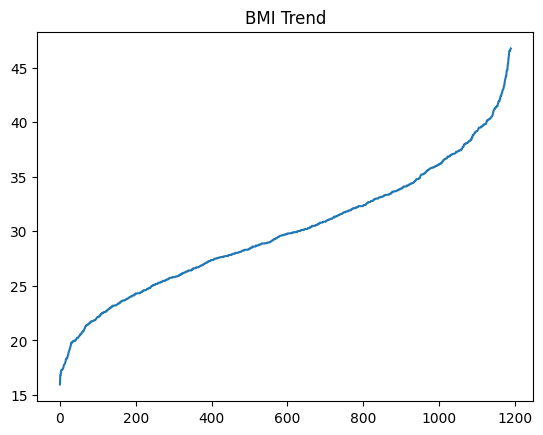

In [85]:
df["bmi"].sort_values().reset_index(drop=True).plot()
plt.title("BMI Trend")
plt.show()

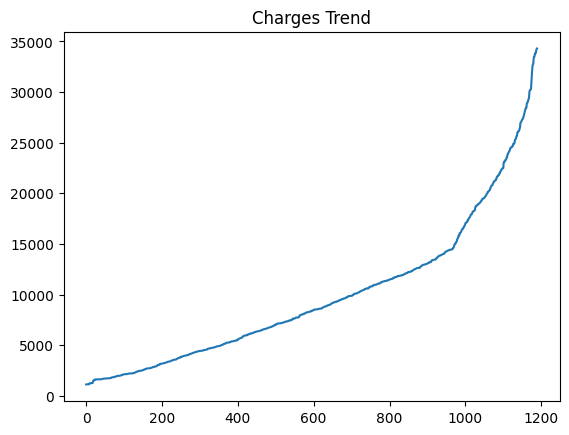

In [86]:
df["charges"].sort_values().reset_index(drop=True).plot()
plt.title("Charges Trend")
plt.show()

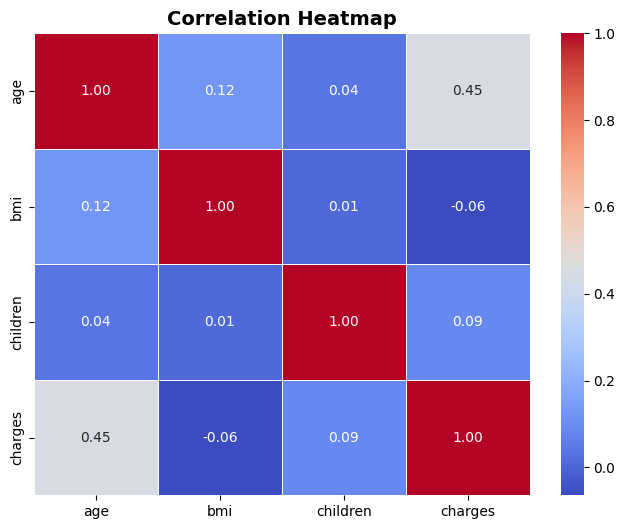

In [87]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap="coolwarm",linewidth=0.5)
plt.title("Correlation Heatmap", fontsize=14,fontweight="bold")
plt.show()

In [88]:
df.info()

<class 'pandas.DataFrame'>
Index: 1190 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1190 non-null   int64  
 1   sex       1190 non-null   str    
 2   bmi       1190 non-null   float64
 3   children  1190 non-null   int64  
 4   smoker    1190 non-null   str    
 5   charges   1190 non-null   float64
dtypes: float64(2), int64(2), str(2)
memory usage: 65.1 KB


In [89]:
df['sex'] = df['sex'].map({'male':0,'female':1})
df['smoker'] = df['smoker'].map({'yes':1,'no':0})


In [90]:
df[['smoker','sex']].isnull().sum()

smoker    0
sex       0
dtype: int64

In [91]:
df.head()

,age,sex,bmi,children,smoker,charges
0,19,1,27.900,0,1,16884.92400
1,18,0,33.770,1,0,1725.55230
2,28,0,33.000,3,0,4449.46200
3,33,0,22.705,0,0,21984.47061
4,32,0,28.880,0,0,3866.85520


In [92]:
df.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
charges     float64
dtype: object

In [111]:
X=df[['age','bmi','smoker','charges']]

In [112]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.42600436, -0.35654991,  2.78388218,  0.97125199],
       [-1.49720586,  0.64335498, -0.3592106 , -1.13908608],
       [-0.78519092,  0.51219198, -0.3592106 , -0.75989026],
       ...,
       [-1.49720586,  1.16800694, -0.3592106 , -1.1524111 ],
       [-1.28360138, -0.71426716, -0.3592106 , -1.09977415],
       [ 1.56445836, -0.1572503 ,  2.78388218,  2.67747205]],
      shape=(1190, 4))

In [113]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for k in range(2,7):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    


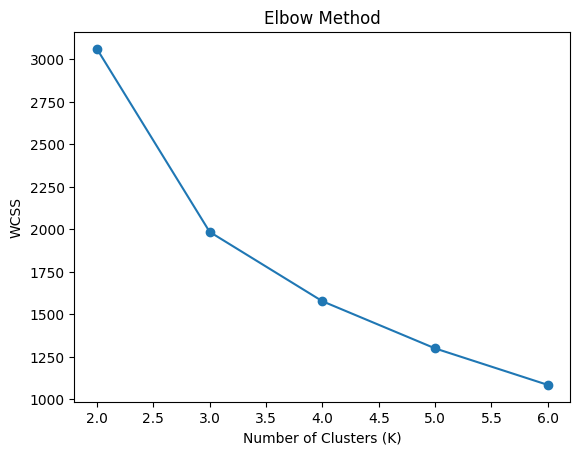

In [114]:
plt.plot(range(2,7), wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [115]:

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

In [116]:
df.sample(5)

,age,sex,bmi,children,smoker,charges,Cluster
1314,30,1,23.655,3,1,18765.87545,1
570,31,1,29.100,0,0,3761.29200,0
1149,42,0,34.100,0,0,5979.73100,2
977,26,0,29.150,1,0,2902.90650,0
1115,55,0,32.670,1,0,10807.48630,2


In [117]:
df["Cluster"].value_counts()

Cluster
0    528
2    526
1    136
Name: count, dtype: int64

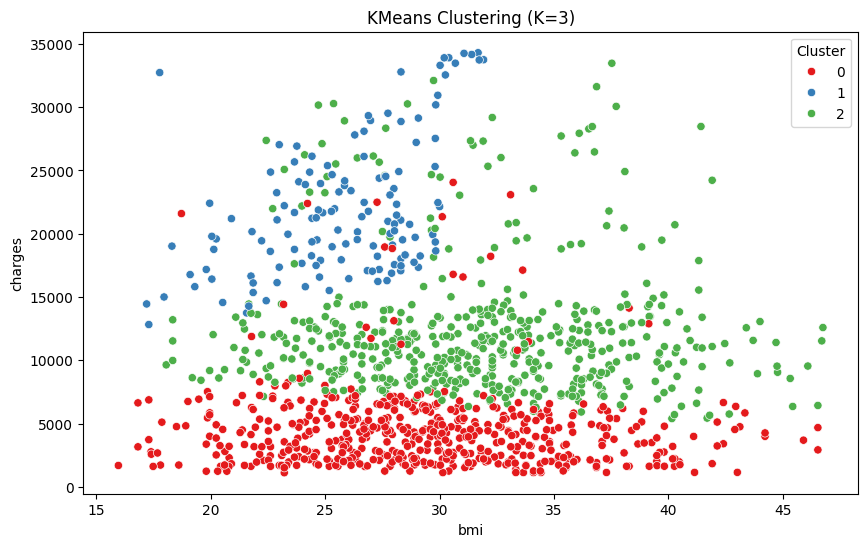

In [118]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='bmi',y='charges',hue='Cluster',data=df,palette='Set1')
plt.title("KMeans Clustering (K=3)")
plt.show()

In [120]:
centres = scaler.inverse_transform(kmeans.cluster_centers_)
print(centres)

[[2.77433962e+01 2.94259717e+01 4.44089210e-16 4.49434221e+03]
 [3.65808824e+01 2.57334926e+01 1.00000000e+00 2.18312734e+04]
 [5.10763359e+01 3.16723760e+01 4.85722573e-16 1.22891620e+04]]


In [121]:
score = silhouette_score(X_scaled,clusters)
print("silhouette_score:",score)

silhouette_score: 0.38254049440773175


In [122]:
df.groupby("Cluster").mean()

,age,sex,bmi,children,smoker,charges
Cluster,,,,,,
0,27.696970,0.507576,29.406468,1.041667,0.0,4487.783618
1,36.580882,0.492647,25.733493,1.080882,1.0,21831.273442
2,51.034221,0.522814,31.683413,1.136882,0.0,12266.107475


In [129]:
new_customer = [[62, 32, 0, 15612.19]]
new_scaled = scaler.transform(new_customer)
cluster = kmeans.predict(new_scaled)

print("Customer belongs to Cluster:", cluster[0])
print("Insurance Type:", customer_types.get(cluster[0], "Unknown"))


IndentationError: unexpected indent (3617125319.py, line 4)